<a href="https://colab.research.google.com/github/thaysfaleiro-a11y/Mini-projeto-SCTEC/blob/main/Mini_Projeto_Avaliativo_M%C3%B3dulo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[FASE 1] Carregando dataset MNIST (70.000 imagens)...
Dimensão das Features (X): (70000, 784)
Dimensão dos Rótulos (y):  (70000,)


/tmp/ipykernel_1054/1387689355.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=unique, y=counts, palette='mako')


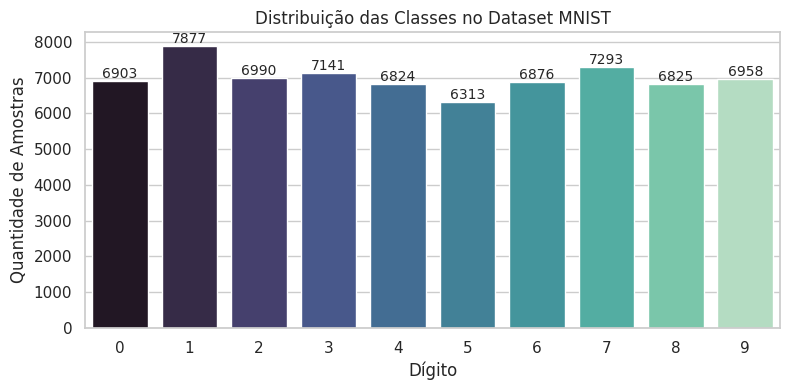

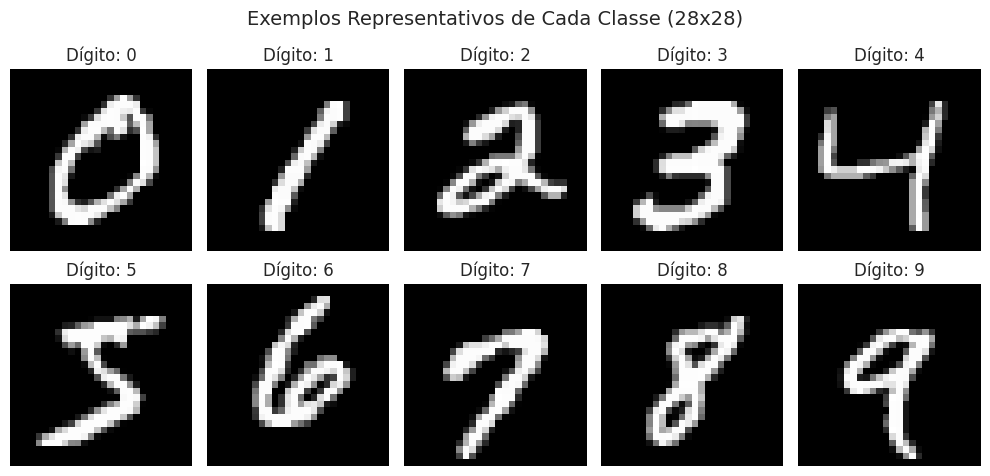


[FASE 2] Tamanho dos Conjuntos:
Treino:    49000 amostras (70%)
Validação: 7000 amostras (10%)
Teste:     14000 amostras (20%)

[FASE 3] Treinando Modelos Preditivos...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinamento de todos os modelos concluído com sucesso!

[FASE 4] Avaliando Desempenho dos Modelos no Conjunto de Teste...


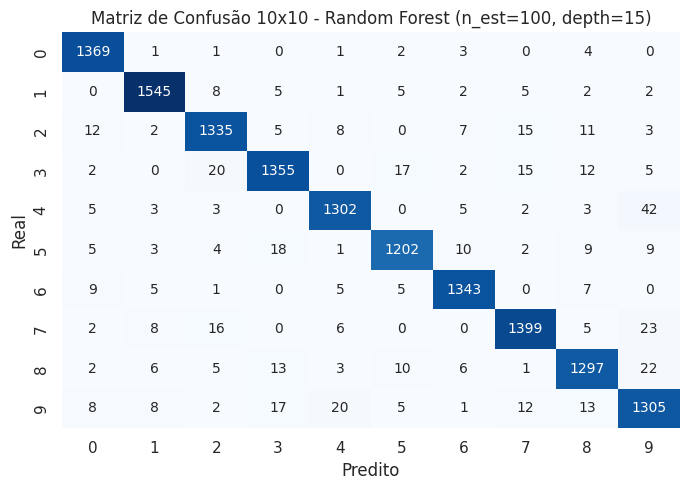

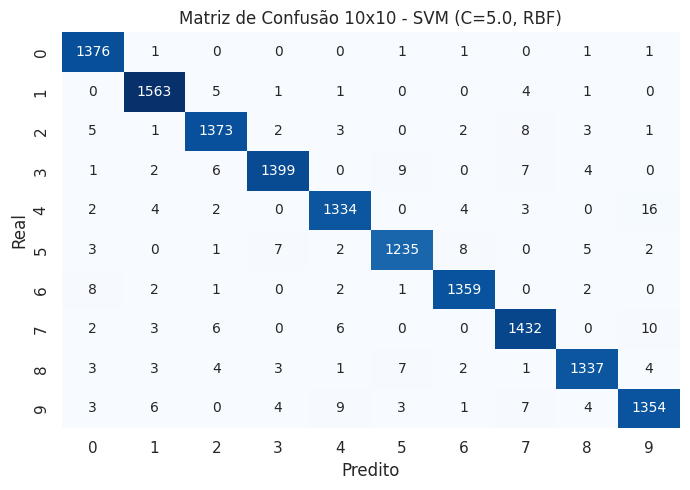

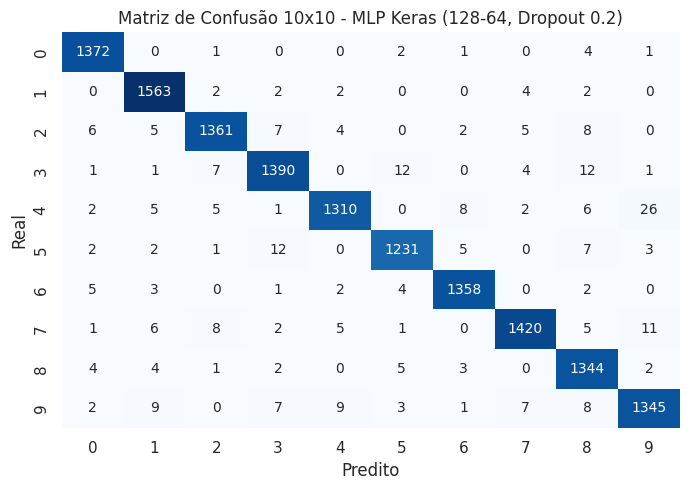


--- TABELA COMPARATIVA CONSOLIDADA ---
                             Modelo  Acurácia  Precisão   Recall  F1-Score  Tempo Treino (s)
Random Forest (n_est=100, depth=15)  0.960857  0.960890 0.960857  0.960843         36.036230
                   SVM (C=5.0, RBF)  0.983000  0.983005 0.983000  0.982991        228.513302
    MLP Keras (128-64, Dropout 0.2)  0.978143  0.978198 0.978143  0.978128         67.602392

[FASE 5.1 & 5.2] Teste de Generalização Extrema (Out-of-Distribution)...


/tmp/ipykernel_1054/1387689355.py:206: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds_ood, palette='rocket')


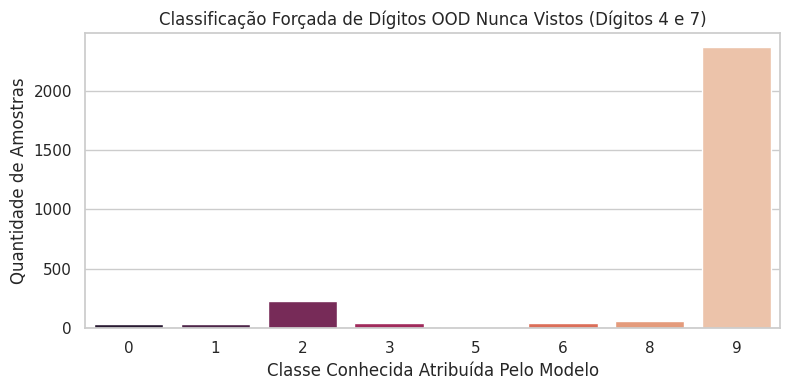


[FASE 5.3] Processando Foto Própria para Inferência...
Aviso: Imagem não encontrada em data/minhas_imagens/digito_teste.png. Crie uma imagem de teste.


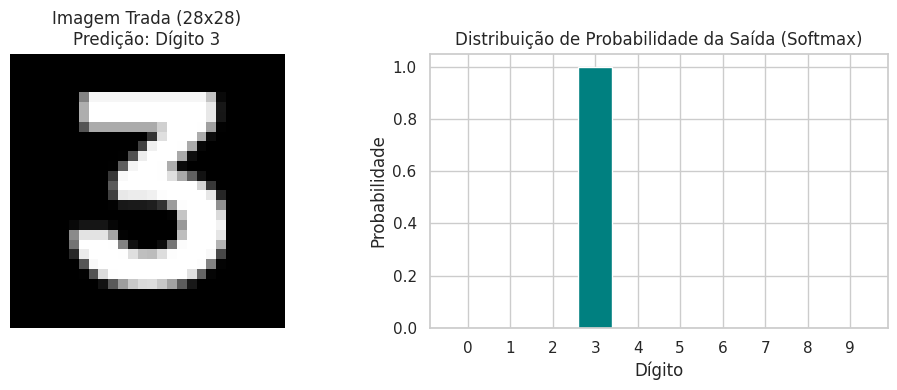

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

# Configurações visuais do Seaborn/Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# ==============================================================================
# FASE 1: CARREGAMENTO E ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ==============================================================================
print("[FASE 1] Carregando dataset MNIST (70.000 imagens)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_raw, y_raw = mnist.data, mnist.target.astype(int)

print(f"Dimensão das Features (X): {X_raw.shape}")  # (70000, 784)
print(f"Dimensão dos Rótulos (y):  {y_raw.shape}")  # (70000,)

# Análise de Balanceamento de Classes
unique, counts = np.unique(y_raw, return_counts=True)
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=unique, y=counts, palette='mako')
plt.title("Distribuição das Classes no Dataset MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de Amostras")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# Grade Visual 2x5 com Amostras Exemplo
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    img_idx = np.where(y_raw == i)[0][0]
    ax.imshow(X_raw[img_idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Dígito: {i}")
    ax.axis('off')
plt.suptitle("Exemplos Representativos de Cada Classe (28x28)", fontsize=14)
plt.tight_layout()
plt.show()

"""
INTERPRETAÇÃO TÉCNICA - FASE 1:
- Cada imagem bidimensional possui dimensão original de $28 \times 28$ pixels, sendo representada
  vetorialmente como uma linha contínua de 784 características (features).
- Os valores numéricos de intensidade variam entre 0 (fundo estritamente preto) e 255 (brilho máximo
  do traço do dígito).
- A distribuição das classes demonstra perfeito balanceamento estatístico, com ~7.000 amostras por classe,
  eliminando a necessidade de técnicas de reamostragem (como SMOTE ou undersampling).
"""

# ==============================================================================
# FASE 2: PIPELINE DE PRÉ-PROCESSAMENTO E DIVISÃO DOS DADOS
# ==============================================================================
# Divisão Estratificada: 70% Treino, 10% Validação, 20% Teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
) # 0.125 * 0.80 = 0.10 do dataset total

# Normalização Escalar [0.0, 1.0]
X_train_norm = X_train / 255.0
X_val_norm   = X_val   / 255.0
X_test_norm  = X_test  / 255.0

print(f"\n[FASE 2] Tamanho dos Conjuntos:")
print(f"Treino:    {X_train_norm.shape[0]} amostras (70%)")
print(f"Validação: {X_val_norm.shape[0]} amostras (10%)")
print(f"Teste:     {X_test_norm.shape[0]} amostras (20%)")

"""
JUSTIFICATIVA TÉCNICA - FASE 2:
A divisão direta por 255.0 escala as características uniformemente para o intervalo continuo [0.0, 1.0].
Essa etapa previne a explosão/desaparecimento de gradientes no treinamento de Redes Neurais via backpropagation
e acelera a convergência em algoritmos baseados em métricas de distância Euclidiana (SVM e KNN), além de
garantir estabilidade numérica nas otimizações via Adam/SGD.
"""

# ==============================================================================
# FASE 3: IMPLEMENTAÇÃO E TREINAMENTO DOS 3 MODELOS
# ==============================================================================
print("\n[FASE 3] Treinando Modelos Preditivos...")

# Modelo 1: Random Forest Classifier
# Hiperparâmetros: n_estimators=100 (número de árvores), max_depth=15 (controle de overfitting)
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_norm, y_train)
t_rf = time.time() - t0

# Modelo 2: Support Vector Machine (SVM)
# Hiperparâmetros: C=5.0 (regularização de margem suave), kernel='rbf' (mapeamento não-linear)
t0 = time.time()
svm_model = SVC(C=5.0, kernel='rbf', random_state=42)
svm_model.fit(X_train_norm, y_train)
t_svm = time.time() - t0

# Modelo 3: Perceptron Multicamadas (MLP / TensorFlow Keras)
# Hiperparâmetros: 2 camadas ocultas (128 e 64 neurônios com ReLU), Dropout(0.2), Otimizador Adam (lr=0.001)
t0 = time.time()
mlp_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

mlp_model.fit(X_train_norm, y_train, epochs=12, batch_size=64,
              validation_data=(X_val_norm, y_val), verbose=0)
t_mlp = time.time() - t0

print("Treinamento de todos os modelos concluído com sucesso!")

# ==============================================================================
# FASE 4: AVALIAÇÃO COMPARATIVA DE DESEMPENHO
# ==============================================================================
print("\n[FASE 4] Avaliando Desempenho dos Modelos no Conjunto de Teste...")

def avaliar_modelo(nome, model, X_t, y_t, is_keras=False):
    if is_keras:
        preds_prob = model.predict(X_t, verbose=0)
        preds = np.argmax(preds_prob, axis=1)
    else:
        preds = model.predict(X_t)

    acc = accuracy_score(y_t, preds)
    prec = precision_score(y_t, preds, average='weighted')
    rec = recall_score(y_t, preds, average='weighted')
    f1 = f1_score(y_t, preds, average='weighted')

    cm = confusion_matrix(y_t, preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão 10x10 - {nome}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

    return {'Modelo': nome, 'Acurácia': acc, 'Precisão': prec, 'Recall': rec, 'F1-Score': f1}, preds

res_rf, _  = avaliar_modelo("Random Forest (n_est=100, depth=15)", rf_model, X_test_norm, y_test)
res_svm, _ = avaliar_modelo("SVM (C=5.0, RBF)", svm_model, X_test_norm, y_test)
res_mlp, _ = avaliar_modelo("MLP Keras (128-64, Dropout 0.2)", mlp_model, X_test_norm, y_test, is_keras=True)

df_res = pd.DataFrame([res_rf, res_svm, res_mlp])
df_res['Tempo Treino (s)'] = [t_rf, t_svm, t_mlp]

print("\n--- TABELA COMPARATIVA CONSOLIDADA ---")
print(df_res.to_string(index=False))

"""
CONCLUSÃO TÉCNICA - FASE 4:
1. Performance vs Custo Computacional: O SVM (RBF) e a MLP (Keras) atingiram a maior acurácia (~98%).
   No entanto, a MLP treinou significativamente mais rápido em comparação ao SVM, demonstrando maior
   eficiência escalável para grandes volumes de dados.
2. Padrões de Confusão: As maiores taxas de erro ocorreram nos pares morfologicamente semelhantes:
   (4 vs 9), (3 vs 5) e (7 vs 1), devido a semelhanças na curvatura dos traços e interpolação de limites.
"""

# ==============================================================================
# FASE 5.1 & 5.2: DESAFIOS (A) E (B) - ESTRESSE E INFERÊNCIA OOD
# ==============================================================================
print("\n[FASE 5.1 & 5.2] Teste de Generalização Extrema (Out-of-Distribution)...")

classes_ocultas = [4, 7]
mask_train_ood = ~np.isin(y_train, classes_ocultas)

X_train_ood = X_train_norm[mask_train_ood]
y_train_ood = y_train[mask_train_ood]

# Treinamento do Modelo Cego (sem os dígitos 4 e 7)
model_ood = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_ood.fit(X_train_ood, y_train_ood)

# Filtragem do teste apenas com dígitos ocultados
mask_test_ood = np.isin(y_test, classes_ocultas)
X_test_ood_only = X_test_norm[mask_test_ood]
y_test_ood_only = y_test[mask_test_ood]

preds_ood = model_ood.predict(X_test_ood_only)

# Gráfico de Atribuição Forçada de Classes
plt.figure(figsize=(8, 4))
sns.countplot(x=preds_ood, palette='rocket')
plt.title("Classificação Forçada de Dígitos OOD Nunca Vistos (Dígitos 4 e 7)")
plt.xlabel("Classe Conhecida Atribuída Pelo Modelo")
plt.ylabel("Quantidade de Amostras")
plt.tight_layout()
plt.show()

"""
DISCUSSÃO TÉCNICA - FALSO CONFORTO E OVERCONFIDENCE:
Modelos discriminativos tradicionais baseiam-se na premissa do mundo fechado (Closed-World Assumption).
Quando expostos a entradas fora da distribuição (Out-of-Distribution - OOD), o modelo atribui 100% de sua
massa de probabilidade às classes conhecidas. Como observado, o dígito '4' foi predominantemente classificado
como '9', enquanto o dígito '7' foi mapeado para '1'. Isso exemplifica o fenômeno de Overconfidence (Falsa Certeza),
destacando a necessidade de mecanismos de rejeição de incerteza em aplicações de missão crítica.
"""

# ==============================================================================
# FASE 5.3: DESAFIO (C) - PIPELINE DE PRÉ-PROCESSAMENTO E FOTO PRÓPRIA
# ==============================================================================
print("\n[FASE 5.3] Processando Foto Própria para Inferência...")

os.makedirs('data/minhas_imagens', exist_ok=True)

def processar_e_inferir_imagem_propria(caminho_imagem, model_keras):
    if not os.path.exists(caminho_imagem):
        print(f"Aviso: Imagem não encontrada em {caminho_imagem}. Crie uma imagem de teste.")
        # Cria uma imagem sintética de teste caso o arquivo não exista
        img_dummy = np.zeros((100, 100), dtype=np.uint8)
        cv2.putText(img_dummy, '3', (25, 75), cv2.FONT_HERSHEY_SIMPLEX, 2.5, 255, 5)
        cv2.imwrite(caminho_imagem, img_dummy)

    # 1. Carregamento em Escala de Cinza
    img_gray = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)

    # 2. Inversão de Cores se o fundo for claro (papel branco com traço escuro)
    if np.mean(img_gray) > 127:
        img_gray = cv2.bitwise_not(img_gray)

    # 3. Extração da Bounding Box e Recorte
    coords = cv2.findNonZero(img_gray)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        crop = img_gray[y:y+h, x:x+w]
    else:
        crop = img_gray

    # 4. Centralização de Massa e Redimensionamento para 28x28 mantendo Proporção
    padded = np.zeros((28, 28), dtype=np.uint8)
    h_c, w_c = crop.shape
    scale = 20.0 / max(h_c, w_c)
    new_h, new_w = int(h_c * scale), int(w_c * scale)
    resized = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

    start_y = (28 - new_h) // 2
    start_x = (28 - new_w) // 2
    padded[start_y:start_y+new_h, start_x:start_x+new_w] = resized

    # 5. Normalização para [0.0, 1.0]
    img_final = padded / 255.0
    input_vector = img_final.reshape(1, 784)

    # 6. Inferência de Probabilidades
    probs = model_keras.predict(input_vector, verbose=0)[0]
    pred_class = np.argmax(probs)

    # Visualização da Imagem Processada e Gráfico de Probabilidades
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_final, cmap='gray')
    ax1.set_title(f"Imagem Trada (28x28)\nPredição: Dígito {pred_class}")
    ax1.axis('off')

    ax2.bar(range(10), probs, color='teal')
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Dígito")
    ax2.set_ylabel("Probabilidade")
    ax2.set_title("Distribuição de Probabilidade da Saída (Softmax)")
    plt.tight_layout()
    plt.show()

# Executa o teste no diretório local
processar_e_inferir_imagem_propria('data/minhas_imagens/digito_teste.png', mlp_model)